# Práctica 4. Primeros circuitos cuánticos con Qiskit

**Duración estimada:** 60–75 minutos   
**Herramientas:** Python, NumPy, Qiskit, Qiskit Aer y Matplotlib

> Completa las celdas marcadas con `TODO` y responde razonadamente en las celdas Markdown. Ejecuta al terminar **Kernel → Restart & Run All**.

## Objetivos

- Crear y visualizar circuitos de uno y dos qubits.
- Diferenciar qubits, bits clásicos, puertas y medidas.
- Preparar $|0\rangle$ y $|1\rangle$.
- Obtener amplitudes y probabilidades exactas con `Statevector`.
- Transpilar y ejecutar circuitos con `AerSimulator`.
- Obtener conteos, frecuencias e histogramas.
- Distinguir simulación exacta y muestreo.
- Interpretar el orden de bits de Qiskit.
- Comparar Qiskit con el formalismo matricial de NumPy.

## Entrega

Entrega este notebook con el nombre:

```text
04_primeros_circuitos_qiskit_apellidos_nombre.ipynb
```

Debe contener código ejecutado, circuitos dibujados, resultados, respuestas, pruebas y una conclusión final. No se aceptarán respuestas compuestas únicamente por código.

# Preparación del entorno

## Ejercicio 1. Instalación y comprobación

Si el entorno no dispone de las bibliotecas, descomenta y ejecuta la siguiente celda una sola vez. Reinicia después el kernel.

In [1]:
# %pip install qiskit qiskit-aer matplotlib pylatexenc

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

np.set_printoptions(precision=5, suppress=True)

print(f"Qiskit:     {qiskit.__version__}")
print(f"Qiskit Aer: {qiskit_aer.__version__}")
print(f"NumPy:      {np.__version__}")

Qiskit:     2.5.2
Qiskit Aer: 0.17.2
NumPy:      2.4.6


### Responde

1. ¿Qué funciones aporta Qiskit?
2. ¿Para qué se utiliza Qiskit Aer?
3. ¿Por qué puede ser necesario reiniciar el kernel después de instalar?
4. ¿Qué biblioteca permite comparar los circuitos con matrices?

**Respuesta:**

1. Qiskit es un kit de desarrollo de código abierto para computación cuántica. Permite construir circuitos cuánticos (`QuantumCircuit`) con qubits, bits clásicos, puertas y medidas, y visualizarlos en texto o con Matplotlib. Con el módulo `quantum_info` se pueden analizar estados y operadores de forma exacta (`Statevector`, `Operator`). Además, incluye un transpilador (`transpile`) que adapta los circuitos a las restricciones de un backend concreto y herramientas para ejecutarlos en simuladores o en hardware cuántico real.

2. Qiskit Aer proporciona simuladores de alto rendimiento, como `AerSimulator`, para ejecutar los circuitos localmente en el ordenador clásico. Simula el proceso de medida repitiendo el circuito un número de veces (*shots*) y devuelve conteos, igual que haría un dispositivo real. Por defecto el simulador es ideal, pero permite añadir modelos de ruido para imitar el comportamiento de un hardware concreto.

3. El kernel es un proceso de Python que ya tiene cargados en memoria los módulos importados. Si se instala o actualiza un paquete mientras el kernel está en marcha, este puede seguir usando la versión antigua (Python guarda los módulos importados en `sys.modules`) o no detectar el paquete nuevo. Al reiniciar, el kernel parte de cero y carga las versiones recién instaladas.

4. NumPy. Con ella se representan los estados como vectores y las puertas como matrices, y se aplican con el producto matricial (`@`). Los resultados se comparan con los de Qiskit mediante `np.allclose()`.

# Parte A. Construcción de circuitos

## Ejercicio 2. Circuito vacío de un qubit

Crea un circuito con un qubit, sin bits clásicos ni puertas. Muestra el circuito, el número de qubits y el número de bits clásicos. Visualízalo en texto y con Matplotlib.

Objeto:    
q: 
   
Tipo: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>
Número de qubits: 1
Número de bits clásicos: 0
Número de operaciones: 0
   
q: 
   


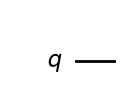

In [3]:
circuito_0 = QuantumCircuit(1)

print("Objeto:", circuito_0)
print("Tipo:", type(circuito_0))
print("Número de qubits:", circuito_0.num_qubits)
print("Número de bits clásicos:", circuito_0.num_clbits)
print("Número de operaciones:", circuito_0.size())

print(circuito_0.draw())
circuito_0.draw("mpl")

### Responde

1. ¿Qué estado tiene inicialmente el qubit?
2. ¿Un circuito vacío carece de estado?
3. ¿Se ha ejecutado al construirlo?
4. ¿Qué diferencia existe entre construir y ejecutar?
5. ¿Qué representa la línea horizontal?

**Respuesta:**

1. Por convenio, en Qiskit todos los qubits se inicializan en el estado $|0\rangle$, cuyo vector es $(1, 0)^T$. Como el circuito no contiene ninguna puerta, el qubit permanece en ese estado.

2. No. Aunque no tenga puertas, el qubit tiene un estado bien definido: el estado inicial $|0\rangle$. Un circuito vacío equivale a aplicar la identidad, de modo que el estado final coincide con el inicial. Lo comprobaremos en el ejercicio 6 con `Statevector`.

3. No. Crear un `QuantumCircuit` solo genera un objeto de Python que describe el circuito: cuántos qubits y bits clásicos tiene y qué instrucciones contiene. No se ha realizado ningún cálculo ni simulación, ni se ha enviado nada a un backend.

4. Construir es definir la "receta" del circuito, es decir, declarar los registros y añadir puertas y medidas en un orden determinado. Ejecutar es entregar esa receta a un backend (un simulador como `AerSimulator` o un ordenador cuántico real), que la procesa y devuelve resultados, normalmente conteos de medidas tras un número de *shots*. Un mismo circuito puede construirse una vez y ejecutarse muchas veces, en distintos backends o con distinto número de shots.

5. Representa el qubit `q` (el qubit 0) a lo largo del tiempo. El tiempo avanza de izquierda a derecha, y las puertas y medidas se dibujan sobre la línea en el orden en que se aplican. Al no haber operaciones, la línea aparece vacía.

## Ejercicio 3. Circuito con un bit clásico
Crea un circuito con un qubit y un bit clásico, pero sin medidas. Consulta sus propiedades y visualízalo.

Número de qubits: 1
Número de bits clásicos: 1
Número de operaciones: 0
     
  q: 
     
c: 1/
     


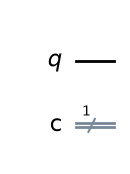

In [4]:
circuito_clasico = QuantumCircuit(1, 1)

print("Número de qubits:", circuito_clasico.num_qubits)
print("Número de bits clásicos:", circuito_clasico.num_clbits)
print("Número de operaciones:", circuito_clasico.size())


print(circuito_clasico.draw())
circuito_clasico.draw("mpl")

### Responde

1. ¿Qué diferencia presenta respecto al circuito anterior?
2. ¿Declarar un bit clásico mide automáticamente?
3. ¿Para qué se utilizará el bit clásico?
4. ¿Puede encontrarse en superposición?

**Respuesta:**

1. Además del qubit, el circuito tiene un registro clásico de un bit, por lo que `num_clbits` vale 1 en lugar de 0. En el dibujo aparece una segunda línea, doble y etiquetada `c`, que representa ese bit clásico. Por lo demás, ambos circuitos son iguales: ninguno contiene puertas ni medidas, y el qubit sigue en $|0\rangle$.

2. No. Declarar un bit clásico solo reserva espacio para guardar un resultado. Para medir hay que añadir explícitamente una instrucción de medida, por ejemplo `measure(0, 0)`. Por eso `size()` sigue valiendo 0 y en el dibujo no aparece ningún símbolo de medida.

3. Para almacenar el resultado de medir el qubit. Cuando se añada `measure(0, 0)`, el resultado de la medida del qubit 0 (un 0 o un 1) se guardará en el bit clásico 0. Esos valores son los que el simulador agrupa después en los conteos.

4. No. Un bit clásico solo puede valer 0 o 1 en cada ejecución, nunca una combinación de ambos. La superposición es una propiedad de los qubits; al medir, el resultado que se escribe en el bit clásico ya es un valor definido.

## Ejercicio 4. Preparación de $|1\rangle$

Crea un circuito de un qubit, aplica $X$ al qubit 0 y visualízalo.

Número de qubits: 1
Número de operaciones: 1
Operaciones: {'x': 1}
   ┌───┐
q: ┤ X ├
   └───┘


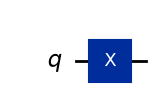

In [5]:
circuito_1 = QuantumCircuit(1)
circuito_1.x(0)

print("Número de qubits:", circuito_1.num_qubits)
print("Número de operaciones:", circuito_1.size())
print("Operaciones:", dict(circuito_1.count_ops()))

print(circuito_1.draw())
circuito_1.draw("mpl")

### Responde

1. ¿Cuál es el estado inicial?
2. ¿Qué transformación realiza $X$?
3. ¿Qué estado debe obtenerse?
4. ¿Qué indica el argumento de `x(0)`?
5. ¿Qué ocurriría al utilizar `x(1)` en este circuito?

**Respuesta:**

1. El qubit parte del estado $|0\rangle = (1, 0)^T$, que es el estado inicial por defecto de todos los qubits en Qiskit.

2. $X$ es la puerta de Pauli X, equivalente cuántico de la puerta NOT clásica. Su matriz es
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$
e intercambia los estados de la base computacional: $X|0\rangle = |1\rangle$ y $X|1\rangle = |0\rangle$. Sobre un estado general, intercambia las amplitudes: $X(\alpha|0\rangle + \beta|1\rangle) = \beta|0\rangle + \alpha|1\rangle$. En la esfera de Bloch corresponde a una rotación de $\pi$ alrededor del eje X.

1. Como $X|0\rangle = |1\rangle$, el estado final debe ser $|1\rangle = (0, 1)^T$. Lo comprobaremos en el ejercicio 7 con `Statevector`.

2. Indica el índice del qubit sobre el que actúa la puerta. En Qiskit los qubits se numeran desde 0, así que `x(0)` aplica $X$ al primer (y único) qubit del circuito.

3. Se produciría un error (`CircuitError`), porque el circuito solo tiene un qubit, con índice 0, y el índice 1 no existe. Qiskit no crea qubits nuevos automáticamente: para usar `x(1)` habría que definir el circuito con al menos dos qubits, por ejemplo `QuantumCircuit(2)`.

## Ejercicio 5. Dos aplicaciones de $X$
Construye y visualiza un circuito con dos puertas $X$ consecutivas sobre el mismo qubit. Predice el estado final antes de simularlo.

Número de qubits: 1
Número de operaciones: 2
Profundidad: 2
Operaciones: {'x': 2}
   ┌───┐┌───┐
q: ┤ X ├┤ X ├
   └───┘└───┘


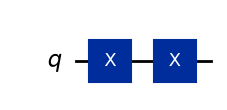

In [6]:
circuito_xx = QuantumCircuit(1)

circuito_xx.x(0)
circuito_xx.x(0)

print("Número de qubits:", circuito_xx.num_qubits)
print("Número de operaciones:", circuito_xx.size())
print("Profundidad:", circuito_xx.depth())
print("Operaciones:", dict(circuito_xx.count_ops()))

print(circuito_xx.draw())
circuito_xx.draw("mpl")

### Responde

1. ¿Cuál debe ser el estado final?
2. ¿Qué relación se cumple entre $X^2$ y la identidad?
3. ¿Importa que ambas puertas actúen sobre el mismo qubit?
4. ¿Se aplican simultáneamente?

**Respuesta:**

1. El estado final debe ser $|0\rangle$. La primera $X$ lleva $|0\rangle$ a $|1\rangle$ y la segunda devuelve $|1\rangle$ a $|0\rangle$:
$$|0\rangle \xrightarrow{X} |1\rangle \xrightarrow{X} |0\rangle$$
Lo comprobaremos en el ejercicio 8 con `Statevector`.

1. Se cumple $X^2 = I$:
$$X^2 = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = I$$
Es decir, $X$ es su propia inversa ($X^{-1} = X$). Esto ocurre porque $X$ es a la vez unitaria ($X^\dagger X = I$) y hermítica ($X^\dagger = X$). Por tanto, aplicar $X$ dos veces sobre cualquier estado lo deja igual.

1. Sí. Solo se anulan porque actúan sobre el mismo qubit, de modo que la segunda deshace lo que hizo la primera. Si actuaran sobre qubits distintos, por ejemplo `x(0)` y `x(1)` en un circuito de dos qubits, cada qubit se invertiría una sola vez y el estado final sería $|11\rangle$ en lugar de $|00\rangle$.

2. No. Se aplican de forma secuencial, en el orden en que aparecen en el circuito (de izquierda a derecha): la segunda $X$ actúa sobre el estado que deja la primera. Por eso la profundidad del circuito es 2. Dos puertas sobre el mismo qubit no pueden aplicarse a la vez; solo puertas sobre qubits distintos pueden ocupar el mismo instante (la misma capa) del circuito.

# Parte B. Vectores de estado

## Ejercicio 6. Estado del circuito vacío

Obtén `Statevector.from_instruction(circuito_0)`. Muestra el objeto, `data`, sus tipos y la forma del array. Compáralo con $|0\rangle=(1,0)^T$.

In [7]:
estado_0 = Statevector.from_instruction(circuito_0)
ket_0_numpy = np.array([1, 0], dtype=complex)

print("Objeto Statevector:")
print(estado_0)
print("Tipo del objeto:", type(estado_0))

print("\nArray data:", estado_0.data)
print("Tipo de data:", type(estado_0.data))
print("Tipo de los elementos:", estado_0.data.dtype)
print("Forma del array:", estado_0.data.shape)
print("Dimensión del estado:", estado_0.dim)

print("\n|0> en NumPy:", ket_0_numpy)
print("¿Coinciden?", np.allclose(estado_0.data, ket_0_numpy))

Objeto Statevector:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Tipo del objeto: <class 'qiskit.quantum_info.states.statevector.Statevector'>

Array data: [1.+0.j 0.+0.j]
Tipo de data: <class 'numpy.ndarray'>
Tipo de los elementos: complex128
Forma del array: (2,)
Dimensión del estado: 2

|0> en NumPy: [1.+0.j 0.+0.j]
¿Coinciden? True


### Responde

1. ¿Qué diferencia existe entre `Statevector` y `data`?
2. ¿Cuántas amplitudes contiene un qubit?
3. ¿Por qué son complejas?
4. ¿Por qué se utiliza `np.allclose()`?

**Respuesta:**

1. `Statevector` es un objeto de Qiskit que representa el estado cuántico completo. Además de las amplitudes, guarda información como la dimensión y el número de subsistemas, y ofrece métodos propios como `probabilities()`, `probabilities_dict()`, `evolve()` o `draw()`. En cambio, `data` es solo un array de NumPy (`numpy.ndarray`) con las amplitudes complejas del estado. Es decir, `data` es el contenido numérico del estado, mientras que `Statevector` es el objeto que lo envuelve y permite trabajar con él.

2. Dos, una por cada estado de la base computacional: la amplitud de $|0\rangle$ y la de $|1\rangle$. En general, un estado de $n$ qubits tiene $2^n$ amplitudes. En este caso, el vector es $(1, 0)^T$: la amplitud de $|0\rangle$ es 1 y la de $|1\rangle$ es 0.

3. Porque en mecánica cuántica las amplitudes son, en general, números complejos: un estado de un qubit es $\alpha|0\rangle + \beta|1\rangle$ con $\alpha, \beta \in \mathbb{C}$ y $|\alpha|^2 + |\beta|^2 = 1$. La parte compleja codifica la fase, que es esencial para la interferencia. Por ejemplo, la puerta $Y$ produce la amplitud $i$. Aunque en este caso las amplitudes sean reales (1 y 0), Qiskit siempre usa el tipo `complex128` para poder representar cualquier estado.

4. Porque los cálculos se hacen con números en coma flotante, que acumulan pequeños errores de redondeo. Por ejemplo, $1/\sqrt{2}$ no puede representarse de forma exacta, así que dos resultados teóricamente iguales pueden diferir en valores del orden de $10^{-16}$. Una comparación exacta con `==` podría dar `False` por esas diferencias. `np.allclose()` compara los arrays elemento a elemento con una tolerancia y devuelve un único booleano que indica si todos los valores coinciden dentro de ella.

## Ejercicio 7. Estado después de $X$
Obtén el vector de `circuito_1`. Muestra norma, amplitudes y probabilidades. Compáralo con $|1\rangle=(0,1)^T$.

In [8]:
estado_1 = Statevector.from_instruction(circuito_1)
ket_1_numpy = np.array([0, 1], dtype=complex)

print("Vector de estado:")
print(estado_1)
print("Array data:", estado_1.data)

norma = np.linalg.norm(estado_1.data)
print("\nNorma:", norma)
print("¿Está normalizado?", np.isclose(norma, 1))

probabilidades = estado_1.probabilities()
print("\nEstado | Amplitud | Probabilidad")
for indice, (amplitud, probabilidad) in enumerate(zip(estado_1.data, probabilidades)):
    print(f"  |{indice}>  | {amplitud:.3f} | {probabilidad:.3f}")

print("\n|1> en NumPy:", ket_1_numpy)
print("¿Coinciden?", np.allclose(estado_1.data, ket_1_numpy))

Vector de estado:
Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
Array data: [0.+0.j 1.+0.j]

Norma: 1.0
¿Está normalizado? True

Estado | Amplitud | Probabilidad
  |0>  | 0.000+0.000j | 0.000
  |1>  | 1.000+0.000j | 1.000

|1> en NumPy: [0.+0.j 1.+0.j]
¿Coinciden? True


### Responde

1. ¿Qué amplitud tiene cada estado de la base?
2. ¿Qué probabilidad tiene cada resultado?
3. ¿Se necesitan shots para obtener este vector?
4. ¿Se ha realizado una medida?

**Respuesta:**

1. El estado es $X|0\rangle = |1\rangle = 0\,|0\rangle + 1\,|1\rangle$. Por tanto, la amplitud de $|0\rangle$ es 0 y la de $|1\rangle$ es 1. El vector es $(0, 1)^T$, que coincide con `ket_1_numpy`, y su norma es 1, como corresponde a un estado cuántico válido.

2. Según la regla de Born, la probabilidad de cada resultado es el módulo al cuadrado de su amplitud: $P(0) = |0|^2 = 0$ y $P(1) = |1|^2 = 1$. Al medir, se obtendría siempre el resultado 1, y las probabilidades suman 1.

3. No. `Statevector.from_instruction()` calcula el estado de forma exacta aplicando al estado inicial las matrices de las puertas del circuito. No simula medidas ni repite el experimento, así que no hay shots ni muestreo: el resultado es el mismo en cada ejecución y no tiene incertidumbre estadística. Los shots solo son necesarios al ejecutar un circuito con medidas en un simulador como `AerSimulator` o en hardware real.

4. No. `circuito_1` no contiene ninguna instrucción de medida, y `Statevector` solo calcula la evolución unitaria del estado. De hecho, `Statevector.from_instruction()` no admite circuitos con medidas. Las probabilidades mostradas son teóricas: indican qué ocurriría si se midiera, pero la medida no se ha hecho.

## Ejercicio 8. Estado después de dos $X$
Obtén el estado exacto de `circuito_xx` y comprueba que coincide con $|0\rangle$.

In [9]:
from qiskit.quantum_info import Operator
estado_xx = Statevector.from_instruction(circuito_xx)

print("Vector de estado:")
print(estado_xx)
print("Array data:", estado_xx.data)
print("Probabilidades:", estado_xx.probabilities_dict())

print("\n¿Coincide con |0> de NumPy?", np.allclose(estado_xx.data, ket_0_numpy))
print("¿Coincide con estado_0?", estado_xx == estado_0)

print("\nOperaciones de circuito_0: ", dict(circuito_0.count_ops()))
print("Operaciones de circuito_xx:", dict(circuito_xx.count_ops()))
print("¿Son el mismo circuito?", circuito_xx == circuito_0)

print("\nOperador de circuito_xx:")
print(Operator(circuito_xx).data)
print("¿Implementan el mismo operador?", Operator(circuito_xx).equiv(Operator(circuito_0)))

Vector de estado:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Array data: [1.+0.j 0.+0.j]
Probabilidades: {np.str_('0'): np.float64(1.0)}

¿Coincide con |0> de NumPy? True
¿Coincide con estado_0? True

Operaciones de circuito_0:  {}
Operaciones de circuito_xx: {'x': 2}
¿Son el mismo circuito? False

Operador de circuito_xx:
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
¿Implementan el mismo operador? True


### Responde

1. ¿Ha cambiado el circuito aunque coincida el estado final?
2. ¿Es igual un circuito vacío a otro con dos puertas $X$?
3. ¿Puede deducirse toda la secuencia observando solo el estado final?

**Respuesta:**

1. Sí. `circuito_xx` contiene dos puertas $X$ y tiene profundidad 2, mientras que `circuito_0` no contiene ninguna operación. Sin embargo, como $X^2 = I$, el estado final de ambos es el mismo, $|0\rangle = (1, 0)^T$. Que el estado final coincida no significa que el circuito no haya cambiado: el qubit ha pasado por el estado intermedio $|1\rangle$ antes de volver a $|0\rangle$.

2. Son equivalentes, pero no iguales. Son equivalentes porque implementan el mismo operador (la identidad), así que producen el mismo estado final a partir de cualquier estado inicial, como confirma `Operator(...).equiv()`. No son iguales porque tienen distinta estructura: distinto número de puertas y distinta profundidad, y Qiskit los considera circuitos diferentes (`circuito_xx == circuito_0` da `False`). En un ordenador cuántico real la diferencia importa: cada puerta tarda un tiempo y añade ruido, así que el circuito con dos $X$ acumularía más error que el vacío. Por eso el transpilador intenta simplificar pares de puertas que se cancelan.

3. No. Muchos circuitos distintos producen el mismo estado final. Por ejemplo, el circuito vacío, $XX$, $HH$ o $ZZ$ dejan el qubit en $|0\rangle$. El estado final solo informa del resultado de la evolución, no del camino seguido para llegar a él. Para conocer la secuencia de operaciones hay que examinar el propio circuito.

## Ejercicio 9. Probabilidades exactas

Para los tres estados anteriores, muestra `probabilities()` y `probabilities_dict()` y construye una tabla comparativa.

In [10]:
estados_exactos = {
    "Vacío": estado_0,
    "Una X": estado_1,
    "Dos X": estado_xx,
}

# Vector y probabilidades de cada estado
for nombre, estado in estados_exactos.items():
    print(f"=== {nombre} ===")
    print("Vector:              ", estado.data)
    print("probabilities():     ", estado.probabilities())
    print("probabilities_dict():", estado.probabilities_dict())
    print()

# Tabla comparativa
print(f"{'Circuito':<8} | {'Amp. |0>':>9} | {'Amp. |1>':>9} | {'P(0)':>5} | {'P(1)':>5} | probabilities_dict()")
print("-" * 75)
for nombre, estado in estados_exactos.items():
    amp_0, amp_1 = estado.data
    p_0, p_1 = estado.probabilities()
    print(f"{nombre:<8} | {amp_0.real:>9.3f} | {amp_1.real:>9.3f} | "
          f"{p_0:>5.2f} | {p_1:>5.2f} | {estado.probabilities_dict()}")

=== Vacío ===
Vector:               [1.+0.j 0.+0.j]
probabilities():      [1. 0.]
probabilities_dict(): {np.str_('0'): np.float64(1.0)}

=== Una X ===
Vector:               [0.+0.j 1.+0.j]
probabilities():      [0. 1.]
probabilities_dict(): {np.str_('1'): np.float64(1.0)}

=== Dos X ===
Vector:               [1.+0.j 0.+0.j]
probabilities():      [1. 0.]
probabilities_dict(): {np.str_('0'): np.float64(1.0)}

Circuito |  Amp. |0> |  Amp. |1> |  P(0) |  P(1) | probabilities_dict()
---------------------------------------------------------------------------
Vacío    |     1.000 |     0.000 |  1.00 |  0.00 | {np.str_('0'): np.float64(1.0)}
Una X    |     0.000 |     1.000 |  0.00 |  1.00 | {np.str_('1'): np.float64(1.0)}
Dos X    |     1.000 |     0.000 |  1.00 |  0.00 | {np.str_('0'): np.float64(1.0)}


### Responde

1. ¿Por qué el diccionario puede omitir resultados de probabilidad cero?
2. ¿Son probabilidades exactas o experimentales?
3. ¿Contienen toda la información del estado?
4. ¿Puede reconstruirse la fase solo con ellas?

**Respuesta:**

1. Porque un resultado que no aparece en el diccionario se interpreta como un resultado con probabilidad cero, así que incluirlo no aporta información. Omitirlo hace la salida más compacta y legible, lo cual es importante con muchos qubits: un estado de $n$ qubits tiene $2^n$ resultados posibles, pero a menudo solo unos pocos tienen probabilidad no nula. `probabilities()`, en cambio, devuelve un array con todos los resultados en el orden de la base, incluidos los ceros. Por esta razón, al consultar el diccionario conviene usar `get(clave, 0)` en lugar de acceder directamente con la clave.

2. Son exactas (teóricas). Se calculan directamente a partir de las amplitudes del vector de estado con la regla de Born, $P(x) = |\langle x|\psi\rangle|^2$, sin medir ni repetir el experimento. Las probabilidades experimentales son las frecuencias relativas que se obtienen al ejecutar el circuito con medidas y un número finito de shots, y en general solo se aproximan a las exactas.

3. No. Las probabilidades solo recogen el módulo al cuadrado de cada amplitud y pierden la fase. Estados distintos pueden tener exactamente las mismas probabilidades: por ejemplo, $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$ y $|-\rangle = (|0\rangle - |1\rangle)/\sqrt{2}$ tienen ambos $P(0) = P(1) = 1/2$, pero son estados diferentes que se comportan de forma distinta ante otras puertas (por ejemplo, $H|+\rangle = |0\rangle$ y $H|-\rangle = |1\rangle$).

4. No. Como $P = |\alpha|^2$, cualquier amplitud $\alpha e^{i\varphi}$ da la misma probabilidad sea cual sea $\varphi$. Por ejemplo, $|1\rangle$ y $i|1\rangle = Y|0\rangle$ tienen las mismas probabilidades. La fase global, como en este ejemplo, no es observable físicamente, pero la fase relativa entre amplitudes sí lo es, como en $|+\rangle$ frente a $|-\rangle$, y no puede recuperarse a partir de las probabilidades en la base computacional. Para obtenerla habría que medir en otras bases o usar el vector de estado completo.

# Parte C. Comparación con NumPy

## Ejercicio 10. Puerta $X$ matricial

Representa $X$, calcula $X|0\rangle$, $X|1\rangle$ y $X^2|0\rangle$, y compara cada resultado con Qiskit.

In [11]:
from qiskit.circuit.library import XGate

X_numpy = np.array([[0, 1],
                    [1, 0]], dtype=complex)

resultado_x_0 = X_numpy @ ket_0_numpy               # X|0>
resultado_x_1 = X_numpy @ ket_1_numpy               # X|1>
resultado_xx_0 = X_numpy @ X_numpy @ ket_0_numpy    # X²|0>

# Matriz X: NumPy frente a Qiskit
print("X en NumPy:")
print(X_numpy)
print("X en Qiskit (Operator):")
print(Operator(XGate()).data)
print("¿Coinciden las matrices?", np.allclose(X_numpy, Operator(XGate()).data))

# X|0>: se compara con el estado de circuito_1
print("\nX|0> NumPy: ", resultado_x_0)
print("X|0> Qiskit:", estado_1.data)
print("¿Coinciden?", np.allclose(resultado_x_0, estado_1.data))

# X|1>: se parte de |1> en Qiskit y se aplica circuito_1 (una X)
estado_x_1_qiskit = Statevector.from_label("1").evolve(circuito_1)
print("\nX|1> NumPy: ", resultado_x_1)
print("X|1> Qiskit:", estado_x_1_qiskit.data)
print("¿Coinciden?", np.allclose(resultado_x_1, estado_x_1_qiskit.data))

# X²|0>: se compara con el estado de circuito_xx
print("\nX²|0> NumPy: ", resultado_xx_0)
print("X²|0> Qiskit:", estado_xx.data)
print("¿Coinciden?", np.allclose(resultado_xx_0, estado_xx.data))

# Comprobación de X² = I
print("\nX² =")
print(X_numpy @ X_numpy)
print("¿X² = I?", np.allclose(X_numpy @ X_numpy, np.eye(2)))

X en NumPy:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X en Qiskit (Operator):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
¿Coinciden las matrices? True

X|0> NumPy:  [0.+0.j 1.+0.j]
X|0> Qiskit: [0.+0.j 1.+0.j]
¿Coinciden? True

X|1> NumPy:  [1.+0.j 0.+0.j]
X|1> Qiskit: [1.+0.j 0.+0.j]
¿Coinciden? True

X²|0> NumPy:  [1.+0.j 0.+0.j]
X²|0> Qiskit: [1.+0.j 0.+0.j]
¿Coinciden? True

X² =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
¿X² = I? True


### Responde

1. ¿Representan NumPy y Qiskit modelos físicos diferentes?
2. ¿Qué elemento de NumPy equivale a una puerta?
3. ¿Qué ventaja proporciona el modelo de circuitos?
4. ¿Por qué sigue siendo útil el formalismo matricial?

**Respuesta:**

1. No. Ambos describen el mismo modelo, el de la mecánica cuántica: los estados son vectores complejos normalizados y las puertas son matrices unitarias que actúan sobre ellos. La diferencia está solo en el nivel de abstracción. En NumPy se escriben y multiplican las matrices a mano, mientras que en Qiskit se describe el circuito y la biblioteca realiza internamente esos mismos cálculos. Por eso todos los resultados coinciden: $X|0\rangle = |1\rangle$, $X|1\rangle = |0\rangle$ y $X^2|0\rangle = |0\rangle$.

2. Una matriz unitaria, en este caso el array bidimensional `X_numpy` de tamaño $2 \times 2$. Los estados equivalen a vectores (arrays unidimensionales como `ket_0_numpy`), y aplicar una puerta equivale al producto matricial `@`. Hay que tener en cuenta el orden: en el circuito las puertas se leen de izquierda a derecha, pero en el producto de matrices se aplican de derecha a izquierda. Una secuencia $A$ y después $B$ corresponde a $B\,A\,|\psi\rangle$.

3. Permite describir algoritmos a alto nivel sin construir las matrices explícitamente. Con $n$ qubits, las matrices son de tamaño $2^n \times 2^n$ y requieren productos tensoriales, lo que se vuelve inmanejable muy rápido. El circuito es más legible (muestra sobre qué qubit actúa cada puerta y en qué orden) e incluye elementos que no son unitarios, como las medidas y los bits clásicos. Además, el mismo circuito puede transpilarse y ejecutarse en simuladores o en hardware cuántico real.

4. Porque es la base matemática que explica lo que hace el circuito. Permite comprender y verificar los resultados de Qiskit, depurar errores y demostrar propiedades algebraicas, como $X^2 = I$ o que una puerta es unitaria ($U^\dagger U = I$). También es la forma más directa de razonar sobre sistemas pequeños, de uno o dos qubits, y de comprobar a mano que un circuito hace lo esperado.

# Parte D. Medida

## Ejercicio 11. Medida de $|0\rangle$

Crea un circuito con un qubit y un bit clásico. Mide el qubit 0 en el bit clásico 0 y visualízalo.

Número de qubits: 1
Número de bits clásicos: 1
Operaciones: {'measure': 1}

Instrucción: measure
¿Es una puerta (Gate)? False
     ┌─┐
  q: ┤M├
     └╥┘
c: 1/═╩═
      0 


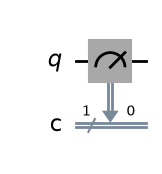

In [12]:
from qiskit.circuit import Gate

circuito_medida_0 = QuantumCircuit(1, 1)

circuito_medida_0.measure(0, 0)

print("Número de qubits:", circuito_medida_0.num_qubits)
print("Número de bits clásicos:", circuito_medida_0.num_clbits)
print("Operaciones:", dict(circuito_medida_0.count_ops()))

instruccion_medida = circuito_medida_0.data[0].operation
print("\nInstrucción:", instruccion_medida.name)
print("¿Es una puerta (Gate)?", isinstance(instruccion_medida, Gate))

print(circuito_medida_0.draw())
circuito_medida_0.draw("mpl")

### Responde

1. ¿Qué significa la flecha de medida?
2. ¿Dónde se almacena el resultado?
3. ¿Cuál debe ser el resultado?
4. ¿La medida es una puerta unitaria?

**Respuesta:**

1. Indica que se mide el qubit y que el resultado se transfiere al registro clásico. El símbolo del medidor (en texto, `M`) se coloca sobre la línea del qubit `q`, y desde él baja una línea doble con una flecha hasta el registro `c`. La línea doble representa información clásica, y el número junto a la flecha (`0`) indica en qué bit clásico se escribe el resultado.

2. En el bit clásico 0 del registro `c`, porque `measure(0, 0)` significa "medir el qubit 0 y guardar el resultado en el bit clásico 0". El primer argumento es el índice del qubit y el segundo el del bit clásico. Al ejecutar el circuito, el simulador recoge el valor de ese bit en cada shot para construir los conteos.

3. Siempre 0. El qubit está en $|0\rangle$, porque no se ha aplicado ninguna puerta antes de medir, y las probabilidades son $P(0) = |1|^2 = 1$ y $P(1) = |0|^2 = 0$. Por tanto, el resultado es determinista: todos los shots darán `0`.

4. No. Las puertas son operaciones unitarias y, por tanto, reversibles: siempre existe una operación que deshace su efecto. La medida, en cambio, es irreversible: proyecta (colapsa) el estado sobre uno de los estados de la base, $|0\rangle$ o $|1\rangle$, y convierte la información cuántica en un bit clásico. Tras medir, se pierden las amplitudes y fases originales y no pueden recuperarse. Por eso Qiskit la trata como una instrucción (`Instruction`) y no como una puerta (`Gate`), y `Statevector.from_instruction()` no admite circuitos con medidas.

## Ejercicio 12. Medida de $|1\rangle$
Construye $|0\rangle\xrightarrow{X}|1\rangle\xrightarrow{medida}1$ y visualízalo.

Número de qubits: 1
Número de bits clásicos: 1
Operaciones: {'x': 1, 'measure': 1}

Orden de las instrucciones:
  0: x
  1: measure

Visualización en texto:
     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

Circuito con la medida antes de X:
     ┌─┐┌───┐
  q: ┤M├┤ X ├
     └╥┘└───┘
c: 1/═╩══════
      0      


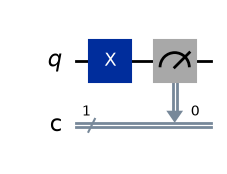

In [32]:
circuito_medida_1 = QuantumCircuit(1, 1)

# Primero X (|0> -> |1>) y después la medida
circuito_medida_1.x(0)
circuito_medida_1.measure(0, 0)

# Propiedades
print("Número de qubits:", circuito_medida_1.num_qubits)
print("Número de bits clásicos:", circuito_medida_1.num_clbits)
print("Operaciones:", dict(circuito_medida_1.count_ops()))

# Orden de las instrucciones
print("\nOrden de las instrucciones:")
for posicion, instruccion in enumerate(circuito_medida_1.data):
    print(f"  {posicion}: {instruccion.operation.name}")

# Visualización en texto
print("\nVisualización en texto:")
print(circuito_medida_1.draw())

# Circuito con el orden invertido (para la pregunta 3)
circuito_medida_antes = QuantumCircuit(1, 1)
circuito_medida_antes.measure(0, 0)
circuito_medida_antes.x(0)
print("\nCircuito con la medida antes de X:")
print(circuito_medida_antes.draw())

# Visualización con Matplotlib
circuito_medida_1.draw("mpl")

### Responde

1. ¿Qué operación se aplica primero?
2. ¿Cómo se identifica el orden temporal?
3. ¿Qué ocurriría si la medida apareciese antes de $X$?
4. ¿El resultado clásico sería el mismo?

**Respuesta:**

1. Primero se aplica la puerta $X$, que transforma $|0\rangle$ en $|1\rangle$, y después la medida, que obtiene el resultado 1 y lo guarda en el bit clásico 0:
$$|0\rangle \xrightarrow{X} |1\rangle \xrightarrow{\text{medida}} 1$$

1. En el diagrama, el tiempo avanza de izquierda a derecha: las operaciones que aparecen más a la izquierda se aplican antes. Aquí la caja $X$ está a la izquierda del medidor. Este orden coincide con el orden en que se añadieron las instrucciones al circuito, que puede consultarse en `circuito.data`.

2. Se mediría el qubit cuando todavía está en $|0\rangle$, así que el resultado sería siempre 0 y se guardaría en el bit clásico. Después, la puerta $X$ cambiaría el qubit a $|1\rangle$, pero ese cambio ya no afectaría al bit clásico, porque la medida se hizo antes y no se vuelve a medir. El estado final del qubit sería $|1\rangle$, pero el resultado registrado sería 0.

3. No. Con $X$ antes de la medida el resultado es siempre 1, y con la medida antes de $X$ es siempre 0. Aunque los dos circuitos contienen exactamente las mismas operaciones, el orden cambia el resultado. En los circuitos cuánticos, como en la multiplicación de matrices, el orden de las operaciones importa.

## Ejercicio 13. `measure_all()`

Crea dos qubits sin bits clásicos, aplica `measure_all()`, visualiza y consulta `num_clbits`.

Antes de measure_all():
  Número de bits clásicos: 0

Después de measure_all():
  Número de qubits: 2
  Número de bits clásicos: 2
  Registros clásicos: [ClassicalRegister(2, 'meas')]
  Operaciones: {'measure': 2, 'barrier': 1}

Correspondencia qubit -> bit clásico:
  q0 -> meas[0]
  q1 -> meas[1]

Visualización en texto:
         ░ ┌─┐   
   q_0: ─░─┤M├───
         ░ └╥┘┌─┐
   q_1: ─░──╫─┤M├
         ░  ║ └╥┘
meas: 2/════╩══╩═
            0  1 


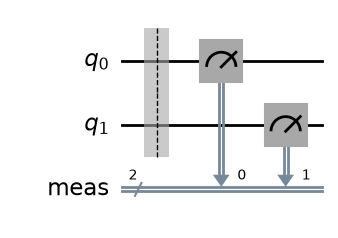

In [33]:
circuito_todos = QuantumCircuit(2)

print("Antes de measure_all():")
print("  Número de bits clásicos:", circuito_todos.num_clbits)

# Medir todos los qubits
circuito_todos.measure_all()

print("\nDespués de measure_all():")
print("  Número de qubits:", circuito_todos.num_qubits)
print("  Número de bits clásicos:", circuito_todos.num_clbits)
print("  Registros clásicos:", circuito_todos.cregs)
print("  Operaciones:", dict(circuito_todos.count_ops()))

# Correspondencia qubit -> bit clásico
print("\nCorrespondencia qubit -> bit clásico:")
for instruccion in circuito_todos.data:
    if instruccion.operation.name == "measure":
        qubit = circuito_todos.find_bit(instruccion.qubits[0]).index
        bit = circuito_todos.find_bit(instruccion.clbits[0]).index
        print(f"  q{qubit} -> meas[{bit}]")

# Visualización en texto
print("\nVisualización en texto:")
print(circuito_todos.draw())

# Visualización con Matplotlib
circuito_todos.draw("mpl")

### Responde

1. ¿Qué ha añadido `measure_all()`?
2. ¿Cuántos bits clásicos aparecen?
3. ¿Qué diferencia presenta respecto a `measure(0, 0)`?
4. ¿Cuándo conviene controlar explícitamente la correspondencia?

**Respuesta:**

1. Ha añadido tres cosas. Primero, un registro clásico nuevo llamado `meas` con tantos bits como qubits tiene el circuito. Segundo, una barrera (`barrier`) que separa las operaciones anteriores de las medidas; la barrera no modifica el estado, pero impide que el transpilador reordene operaciones a través de ella. Tercero, una medida por cada qubit, que guarda el resultado del qubit $i$ en el bit clásico $i$ del registro `meas`.

2. Dos, uno por cada qubit, en el registro `meas`. Antes de llamar a `measure_all()`, el circuito no tenía ningún bit clásico (`num_clbits` valía 0).

3. `measure(0, 0)` mide un único qubit y exige que el circuito ya tenga el bit clásico de destino. Además, el programador decide explícitamente qué qubit se mide y en qué bit se guarda. `measure_all()` mide todos los qubits de una vez, crea automáticamente el registro clásico necesario, añade una barrera y fija la correspondencia $q_i \rightarrow \text{meas}[i]$ sin posibilidad de elegirla. Si el circuito ya tuviera bits clásicos propios, `measure_all()` añadiría igualmente el registro `meas`, y las cadenas de resultados incluirían los bits de ambos registros separados por un espacio.

4. Conviene usar `measure()` con índices explícitos en varios casos: cuando solo interesa medir algunos qubits, cuando el circuito ya tiene registros clásicos definidos, cuando se necesita un orden concreto de los bits en las cadenas de resultados (ver el ejercicio 28), cuando se mide a mitad de circuito o cuando el resultado se usará para condicionar operaciones posteriores. En esos casos, la correspondencia automática de `measure_all()` puede producir bits de más o un orden distinto del esperado.

# Parte E. Ejecución con Aer

## Ejercicio 14. Simulador y transpilación

Crea `AerSimulator()`. Transpila los circuitos de medida de $|0\rangle$ y $|1\rangle$ para ese backend y visualiza los resultados.

Simulador: AerSimulator('aer_simulator')
Nombre: aer_simulator
Tipo: <class 'qiskit_aer.backends.aer_simulator.AerSimulator'>

=== Circuito de medida de |0> ===
Operaciones originales:   {'measure': 1}
Operaciones transpiladas: {'measure': 1}
Profundidad original / transpilada: 1 / 1
¿Es el mismo objeto? False
     ┌─┐
  q: ┤M├
     └╥┘
c: 1/═╩═
      0 

=== Circuito de medida de |1> ===
Operaciones originales:   {'x': 1, 'measure': 1}
Operaciones transpiladas: {'x': 1, 'measure': 1}
Profundidad original / transpilada: 2 / 2
¿Es el mismo objeto? False
     ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


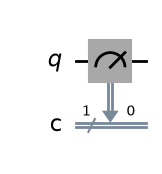

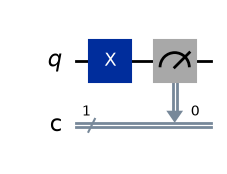

In [34]:
simulador = AerSimulator()

circuito_0_transpilado = transpile(circuito_medida_0, simulador)
circuito_1_transpilado = transpile(circuito_medida_1, simulador)

# Simulador
print("Simulador:", simulador)
print("Nombre:", simulador.name)
print("Tipo:", type(simulador))

# Comparación antes y después de transpilar
comparacion = {
    "|0>": (circuito_medida_0, circuito_0_transpilado),
    "|1>": (circuito_medida_1, circuito_1_transpilado),
}
for nombre, (original, transpilado) in comparacion.items():
    print(f"\n=== Circuito de medida de {nombre} ===")
    print("Operaciones originales:  ", dict(original.count_ops()))
    print("Operaciones transpiladas:", dict(transpilado.count_ops()))
    print("Profundidad original / transpilada:", original.depth(), "/", transpilado.depth())
    print("¿Es el mismo objeto?", original is transpilado)
    print(transpilado.draw())

# Visualización con Matplotlib
display(circuito_0_transpilado.draw("mpl"))
display(circuito_1_transpilado.draw("mpl"))

### Responde

1. ¿El simulador es el circuito?
2. ¿Por qué se adapta un circuito al backend?
3. ¿Qué finalidad tendrá la transpilación en hardware real?
4. ¿Un simulador ideal incorpora automáticamente ruido?

**Respuesta:**

1. No. El circuito es la descripción del experimento (qué qubits hay, qué puertas se aplican y qué se mide), mientras que el simulador es el backend que ejecuta esa descripción y produce resultados. `AerSimulator` desempeña en el ordenador clásico el papel que tendría un ordenador cuántico real. Un mismo simulador puede ejecutar muchos circuitos distintos, y un mismo circuito puede ejecutarse en distintos backends.

2. Porque cada backend tiene sus propias restricciones: un conjunto limitado de puertas nativas (la *basis gates*), un número máximo de qubits y, en hardware real, una conectividad concreta entre qubits. La transpilación reescribe el circuito para que cumpla esas restricciones sin cambiar su efecto, y además puede optimizarlo, por ejemplo eliminando puertas que se cancelan. En este caso, como `AerSimulator` admite directamente `x` y `measure`, los circuitos transpilados son iguales a los originales.

3. En un ordenador cuántico real, la transpilación descompone las puertas en las puertas nativas del dispositivo, asigna los qubits lógicos del circuito a qubits físicos concretos y añade puertas SWAP cuando dos qubits que deben interactuar no están conectados directamente. También optimiza el circuito para reducir el número de puertas y la profundidad. Esto es fundamental porque cada puerta tarda un tiempo e introduce errores, así que un circuito más corto obtiene resultados más fiables.

4. No. Por defecto, `AerSimulator()` simula un ordenador cuántico ideal, sin errores en las puertas, en las medidas ni por decoherencia. Los resultados solo presentan la aleatoriedad propia de la mecánica cuántica al medir estados en superposición. Para simular ruido hay que indicarlo explícitamente, por ejemplo con un modelo de ruido (`NoiseModel`) o creando el simulador a partir de las características de un dispositivo real.

## Ejercicio 15. Ejecución de $|0\rangle$
Ejecuta 1.000 shots con `seed_simulator=42`. Recupera el trabajo, el resultado y los conteos. Comprueba la suma.

In [35]:
trabajo_0 = simulador.run(circuito_0_transpilado, shots=1000, seed_simulator=42)
resultado_0 = trabajo_0.result()
conteos_0 = resultado_0.get_counts()

# Trabajo
print("Trabajo:", trabajo_0)
print("Tipo:", type(trabajo_0))
print("Identificador:", trabajo_0.job_id())
print("Estado:", trabajo_0.status())

# Resultado
print("\nTipo del resultado:", type(resultado_0))
print("¿Ejecución correcta?", resultado_0.success)
print("Backend:", resultado_0.backend_name)

# Conteos
print("\nConteos:", conteos_0)
print("Tipo de los conteos:", type(conteos_0))

# Comprobación del total
total_0 = sum(conteos_0.values())
print("\nTotal de conteos:", total_0)
print("¿Suman 1000?", total_0 == 1000)
print("¿Todos los resultados son '0'?", conteos_0.get("0", 0) == 1000)

Trabajo: <qiskit_aer.jobs.aerjob.AerJob object at 0x115f91d90>
Tipo: <class 'qiskit_aer.jobs.aerjob.AerJob'>
Identificador: 7a8e90f9-55d8-4bf8-8b36-30cc1b33b9c7
Estado: JobStatus.DONE

Tipo del resultado: <class 'qiskit.result.result.Result'>
¿Ejecución correcta? True
Backend: aer_simulator

Conteos: {'0': 1000}
Tipo de los conteos: <class 'qiskit.result.counts.Counts'>

Total de conteos: 1000
¿Suman 1000? True
¿Todos los resultados son '0'? True


### Responde

1. ¿Qué representa el trabajo?
2. ¿Qué devuelve `result()`?
3. ¿Qué devuelve `get_counts()`?
4. ¿Cuánto suman los conteos?
5. ¿Por qué el resultado es determinista?

**Respuesta:**

1. El trabajo (*job*), de tipo `AerJob`, representa la tarea de ejecución que se ha enviado al backend con `simulador.run()`. No contiene directamente los resultados: es un objeto que permite seguir la ejecución, consultar su identificador (`job_id()`) y su estado (`status()`), y recuperar los resultados cuando termina. Esta separación tiene sentido en hardware real, donde los trabajos se ponen en cola y pueden tardar en completarse.

2. Devuelve un objeto `Result` con toda la información de la ejecución: si ha terminado correctamente (`success`), el backend utilizado, el número de shots y los datos obtenidos para cada circuito. Si el trabajo aún no hubiera terminado, `result()` esperaría hasta que finalizase.

3. Devuelve un diccionario (de tipo `Counts`) cuyas claves son las cadenas de bits obtenidas al medir y cuyos valores son el número de shots en que apareció cada cadena. Solo incluye los resultados que han aparecido al menos una vez. En este caso es `{'0': 1000}`.

4. Suman 1000, que es exactamente el número de shots, porque cada shot produce un único resultado. Esta comprobación sirve para verificar que no se ha perdido ningún resultado.

5. Porque el qubit se mide en el estado $|0\rangle$, en el que $P(0) = 1$ y $P(1) = 0$. Cuando el estado es un estado de la base computacional, la medida da siempre el mismo resultado, así que los 1000 shots producen `0` y no hay aleatoriedad. La semilla `seed_simulator=42` no es la causa: solo hace reproducible el muestreo aleatorio en estados en superposición (Parte G). Aquí el resultado sería el mismo con cualquier semilla o sin ella.

## Ejercicio 16. Ejecución de $|1\rangle$
Ejecuta 10, 100, 1.000 y 10.000 shots. Para cada caso calcula conteos y frecuencias.

In [36]:
shots_estudiados_determinista = [10, 100, 1_000, 10_000]
resultados_deterministas = []

for shots in shots_estudiados_determinista:
    trabajo = simulador.run(circuito_1_transpilado, shots=shots, seed_simulator=42)
    conteos = trabajo.result().get_counts()

    conteo_0 = conteos.get("0", 0)
    conteo_1 = conteos.get("1", 0)

    resultados_deterministas.append({
        "shots": shots,
        "conteos": conteos,
        "conteo_0": conteo_0,
        "conteo_1": conteo_1,
        "frecuencia_0": conteo_0 / shots,
        "frecuencia_1": conteo_1 / shots,
    })

# Tabla de resultados
print(f"{'Shots':>6} | {'Conteos':<15} | {'n(0)':>5} | {'n(1)':>6} | {'f(0)':>5} | {'f(1)':>5} | Total correcto")
print("-" * 72)
for fila in resultados_deterministas:
    total_correcto = fila["conteo_0"] + fila["conteo_1"] == fila["shots"]
    print(f"{fila['shots']:>6} | {str(fila['conteos']):<15} | {fila['conteo_0']:>5} | "
          f"{fila['conteo_1']:>6} | {fila['frecuencia_0']:>5.2f} | {fila['frecuencia_1']:>5.2f} | {total_correcto}")

 Shots | Conteos         |  n(0) |   n(1) |  f(0) |  f(1) | Total correcto
------------------------------------------------------------------------
    10 | {'1': 10}       |     0 |     10 |  0.00 |  1.00 | True
   100 | {'1': 100}      |     0 |    100 |  0.00 |  1.00 | True
  1000 | {'1': 1000}     |     0 |   1000 |  0.00 |  1.00 | True
 10000 | {'1': 10000}    |     0 |  10000 |  0.00 |  1.00 | True


### Responde

1. ¿Por qué conviene utilizar `get()`?
2. ¿Cambia la distribución al aumentar los shots?
3. ¿Aporta información nueva usar 10.000 shots en este caso?
4. ¿Aparece incertidumbre estadística en el simulador ideal?

**Respuesta:**

1. Porque `get_counts()` solo incluye los resultados que han aparecido al menos una vez. En este circuito nunca se obtiene `0`, así que la clave `"0"` no existe en el diccionario y acceder con `conteos["0"]` produciría un `KeyError`. Con `conteos.get("0", 0)` se obtiene el valor 0 cuando la clave no está, lo que corresponde exactamente a su significado: ese resultado ha aparecido cero veces.

2. No. Con cualquier número de shots, todos los resultados son `1`, así que las frecuencias son siempre $f(0) = 0$ y $f(1) = 1$. Solo cambian los conteos absolutos, que crecen en proporción al número de shots.

3. No. Como el estado medido es $|1\rangle$, con $P(1) = 1$, el resultado es determinista: con 10 shots ya se obtiene la distribución exacta, y repetir más veces solo reproduce el mismo resultado. Aumentar los shots solo tiene sentido cuando el resultado es aleatorio, como en los estados en superposición, donde más shots permiten aproximar mejor las probabilidades.

4. En este caso no, porque medir un estado de la base computacional da siempre el mismo resultado y un simulador ideal no introduce errores. Sin embargo, el simulador ideal sí puede mostrar incertidumbre estadística cuando se mide un estado en superposición: la aleatoriedad procede de la propia medida cuántica, no del ruido. Por eso, con $|+\rangle$ (Parte G) las frecuencias fluctuarán alrededor de 0,5 aunque el simulador sea ideal.

# Parte F. Conteos e histogramas

## Ejercicio 17. Función de ejecución

Implementa una función que valide `shots`, transpile, ejecute y devuelva conteos.

In [37]:
def ejecutar_con_shots(circuito, shots=1000, semilla=42):
    """Transpila y ejecuta un circuito con medidas.

    Parámetros
    ----------
    circuito : QuantumCircuit
        Circuito que contiene al menos una medida.
    shots : int
        Número de repeticiones (entero positivo).
    semilla : int o None
        Semilla del simulador para obtener resultados reproducibles.

    Devuelve
    --------
    dict
        Diccionario de conteos {cadena_de_bits: número_de_apariciones}.
    """
    # Validación del circuito
    if not isinstance(circuito, QuantumCircuit):
        raise TypeError("El circuito debe ser un QuantumCircuit.")
    if circuito.count_ops().get("measure", 0) == 0:
        raise ValueError("El circuito debe contener al menos una medida.")

    # Validación de shots (bool es subclase de int, así que se excluye)
    if isinstance(shots, bool) or not isinstance(shots, int):
        raise TypeError("shots debe ser un número entero.")
    if shots <= 0:
        raise ValueError("shots debe ser un entero positivo.")

    simulador = AerSimulator()
    circuito_transpilado = transpile(circuito, simulador)
    trabajo = simulador.run(circuito_transpilado, shots=shots, seed_simulator=semilla)
    return trabajo.result().get_counts()


# Pruebas con |0> y |1>
conteos_prueba_0 = ejecutar_con_shots(circuito_medida_0)
conteos_prueba_1 = ejecutar_con_shots(circuito_medida_1, shots=500)

print("Conteos |0> (1000 shots):", conteos_prueba_0)
print("Conteos |1> (500 shots): ", conteos_prueba_1)

assert conteos_prueba_0 == {"0": 1000}
assert conteos_prueba_1 == {"1": 500}
assert sum(conteos_prueba_0.values()) == 1000
assert sum(conteos_prueba_1.values()) == 500

# Pruebas con entradas inválidas
casos_invalidos = [
    ("shots = 0", circuito_medida_0, 0),
    ("shots negativos", circuito_medida_0, -10),
    ("shots no entero", circuito_medida_0, 10.5),
    ("shots booleano", circuito_medida_0, True),
    ("circuito sin medidas", circuito_1, 100),
    ("objeto que no es circuito", "no es un circuito", 100),
]

print("\nPruebas con entradas inválidas:")
for descripcion, circ, n_shots in casos_invalidos:
    try:
        ejecutar_con_shots(circ, shots=n_shots)
        print(f"  {descripcion}: NO se ha detectado el error")
    except (TypeError, ValueError) as error:
        print(f"  {descripcion}: {type(error).__name__} -> {error}")

Conteos |0> (1000 shots): {'0': 1000}
Conteos |1> (500 shots):  {'1': 500}

Pruebas con entradas inválidas:
  shots = 0: ValueError -> shots debe ser un entero positivo.
  shots negativos: ValueError -> shots debe ser un entero positivo.
  shots no entero: TypeError -> shots debe ser un número entero.
  shots booleano: TypeError -> shots debe ser un número entero.
  circuito sin medidas: ValueError -> El circuito debe contener al menos una medida.
  objeto que no es circuito: TypeError -> El circuito debe ser un QuantumCircuit.


## Ejercicio 18. Frecuencias

Implementa una función que convierta conteos en frecuencias y rechace diccionarios vacíos, conteos negativos, no enteros o con total cero.

In [38]:
from numbers import Integral

def calcular_frecuencias(conteos):
    """Convierte un diccionario de conteos en frecuencias relativas.

    Parámetros
    ----------
    conteos : dict
        Diccionario {resultado: número_de_apariciones} con enteros no negativos.

    Devuelve
    --------
    dict
        Diccionario {resultado: frecuencia_relativa}, cuyas frecuencias suman 1.
    """
    if not isinstance(conteos, dict):
        raise TypeError("Los conteos deben ser un diccionario.")
    if len(conteos) == 0:
        raise ValueError("El diccionario de conteos está vacío.")

    for resultado, conteo in conteos.items():
        # bool es subclase de int, así que se excluye explícitamente
        if isinstance(conteo, bool) or not isinstance(conteo, Integral):
            raise TypeError(f"El conteo de '{resultado}' no es un entero: {conteo!r}")
        if conteo < 0:
            raise ValueError(f"El conteo de '{resultado}' es negativo: {conteo}")

    total = sum(conteos.values())
    if total == 0:
        raise ValueError("El total de conteos es cero; no se pueden calcular frecuencias.")

    return {resultado: conteo / total for resultado, conteo in conteos.items()}


# Prueba principal
conteos_ejemplo = {"0": 250, "1": 750}
frecuencias_ejemplo = calcular_frecuencias(conteos_ejemplo)

print("Conteos:    ", conteos_ejemplo)
print("Frecuencias:", frecuencias_ejemplo)
print("Suma de frecuencias:", sum(frecuencias_ejemplo.values()))

assert np.isclose(frecuencias_ejemplo["0"], 0.25)
assert np.isclose(frecuencias_ejemplo["1"], 0.75)
assert np.isclose(sum(frecuencias_ejemplo.values()), 1)

# Prueba con conteos reales del simulador
print("\nFrecuencias de |0>:", calcular_frecuencias(conteos_0))
print("Frecuencias de |1>:", calcular_frecuencias(conteos_prueba_1))

# Pruebas con entradas inválidas
casos_invalidos = [
    ("diccionario vacío", {}),
    ("conteo negativo", {"0": -5, "1": 10}),
    ("conteo no entero", {"0": 2.5, "1": 7}),
    ("conteo booleano", {"0": True, "1": 3}),
    ("total cero", {"0": 0, "1": 0}),
    ("no es un diccionario", [250, 750]),
]

print("\nPruebas con entradas inválidas:")
for descripcion, entrada in casos_invalidos:
    try:
        calcular_frecuencias(entrada)
        print(f"  {descripcion}: NO se ha detectado el error")
    except (TypeError, ValueError) as error:
        print(f"  {descripcion}: {type(error).__name__} -> {error}")

Conteos:     {'0': 250, '1': 750}
Frecuencias: {'0': 0.25, '1': 0.75}
Suma de frecuencias: 1.0

Frecuencias de |0>: {'0': 1.0}
Frecuencias de |1>: {'1': 1.0}

Pruebas con entradas inválidas:
  diccionario vacío: ValueError -> El diccionario de conteos está vacío.
  conteo negativo: ValueError -> El conteo de '0' es negativo: -5
  conteo no entero: TypeError -> El conteo de '0' no es un entero: 2.5
  conteo booleano: TypeError -> El conteo de '0' no es un entero: True
  total cero: ValueError -> El total de conteos es cero; no se pueden calcular frecuencias.
  no es un diccionario: TypeError -> Los conteos deben ser un diccionario.


### Responde

1. ¿Qué diferencia existe entre conteo y frecuencia?
2. ¿Qué deben sumar las frecuencias?
3. ¿Equivale una frecuencia a una amplitud?
4. ¿Puede recuperarse el signo de una amplitud a partir de conteos?

**Respuesta:**

1. El conteo es el número absoluto de veces que aparece un resultado; es un entero que depende del número de shots. La frecuencia (relativa) es la proporción de shots en que aparece: $f(x) = n(x) / N$, donde $N$ es el total de shots. Es un número entre 0 y 1 que permite comparar ejecuciones con distinto número de shots. Por ejemplo, 250 de 1000 y 25 de 100 son conteos distintos pero la misma frecuencia, 0,25.

2. Deben sumar 1 (salvo pequeños errores de redondeo en coma flotante), porque cada shot produce exactamente un resultado y, por tanto, la suma de los conteos es igual al número total de shots. En el ejemplo: $0{,}25 + 0{,}75 = 1$.

3. No. La amplitud es un número complejo que forma parte del vector de estado, mientras que la frecuencia es un número real entre 0 y 1 obtenido experimentalmente. La frecuencia es una estimación de la probabilidad, que a su vez es el módulo al cuadrado de la amplitud: $f(x) \approx P(x) = |\alpha_x|^2$. Hay dos pasos de diferencia: la frecuencia solo se aproxima a la probabilidad (con un número finito de shots), y la probabilidad pierde la fase de la amplitud.

4. No. Los conteos solo permiten estimar las probabilidades $|\alpha_x|^2$, y el cuadrado del módulo es el mismo para $\alpha$ y $-\alpha$ (y en general para $\alpha e^{i\varphi}$). Por ejemplo, $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$ y $|-\rangle = (|0\rangle - |1\rangle)/\sqrt{2}$ producen, al medirlos en la base computacional, los mismos conteos en promedio (aproximadamente mitad `0` y mitad `1`), aunque el signo de la amplitud de $|1\rangle$ es distinto. Para detectar esa diferencia habría que aplicar otra puerta antes de medir (por ejemplo, $H$) o medir en otra base.

## Ejercicio 19. Histogramas
Representa por separado los conteos de $|0\rangle$ y $|1\rangle$ y después ambos en una misma figura con leyenda.

Conteos |0>: {'0': 1000}
Conteos |1>: {'1': 1000}


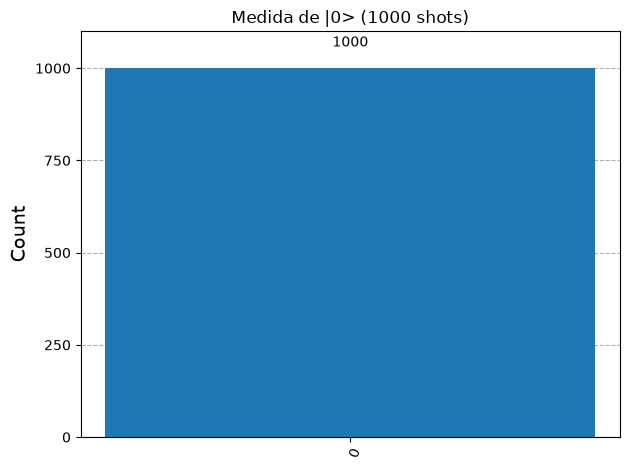

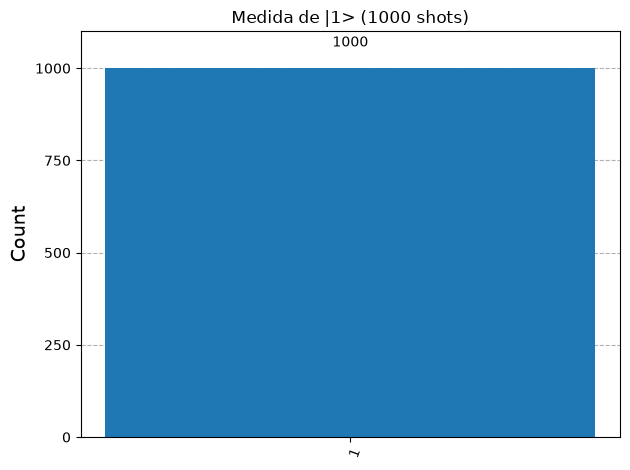

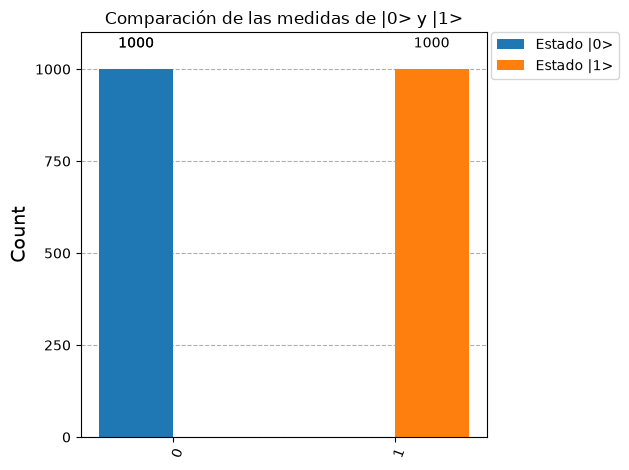

In [39]:
# Conteos de |1> con 1000 shots (en el ejercicio 17 usamos 500)
conteos_1 = ejecutar_con_shots(circuito_medida_1, shots=1000)

print("Conteos |0>:", conteos_0)
print("Conteos |1>:", conteos_1)

# Histograma de |0>
display(plot_histogram(conteos_0, title="Medida de |0> (1000 shots)"))

# Histograma de |1>
display(plot_histogram(conteos_1, title="Medida de |1> (1000 shots)"))

# Ambos en una misma figura con leyenda
display(plot_histogram(
    [conteos_0, conteos_1],
    legend=["Estado |0>", "Estado |1>"],
    title="Comparación de las medidas de |0> y |1>",
))

### Responde

1. ¿Qué información representa el histograma?
2. ¿Muestra el circuito o el vector de estado?
3. ¿Muestra amplitudes o fases?

**Respuesta:**

1. Representa los resultados experimentales de la ejecución: en el eje horizontal, las cadenas de bits obtenidas al medir y, en el eje vertical, el número de veces que apareció cada una (los conteos) sobre el total de shots. Es una representación gráfica del diccionario devuelto por `get_counts()`. En este caso, cada histograma tiene una única barra de altura 1000: el estado $|0\rangle$ da siempre `0` y el estado $|1\rangle$ da siempre `1`. La figura combinada permite comparar ambas distribuciones de un vistazo.

2. Ninguno de los dos. El histograma no muestra qué puertas se aplicaron (eso lo muestra `draw()`) ni el estado cuántico antes de medir (eso lo muestra `Statevector`). Solo muestra los resultados de las medidas. Circuitos distintos, como el vacío y el de dos $X$, producirían histogramas idénticos.

3. No. El histograma muestra conteos, que permiten estimar las probabilidades $|\alpha_x|^2$, pero no las amplitudes complejas ni sus fases, porque esa información se pierde al medir. Por ejemplo, los estados $X|0\rangle = |1\rangle$ e $Y|0\rangle = i|1\rangle$ darían exactamente el mismo histograma, aunque sus amplitudes sean distintas.

# Parte G. Simulación exacta y muestreo

## Ejercicio 20. Primera superposición

Crea un circuito con una puerta $H$, obtén su vector y compáralo con $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$. Muestra probabilidades exactas.

Circuito:
   ┌───┐
q: ┤ H ├
   └───┘
Matriz de H:
[[ 0.70711+0.j  0.70711+0.j]
 [ 0.70711+0.j -0.70711+0.j]]

Amplitudes Qiskit: [0.70711+0.j 0.70711+0.j]
Amplitudes NumPy:  [0.70711+0.j 0.70711+0.j]
¿Coinciden las amplitudes? True
Norma: 0.9999999999999999

Probabilidades Qiskit: [0.5 0.5]
Probabilidades NumPy:  [0.5 0.5]
probabilities_dict(): {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
¿Coinciden las probabilidades? True


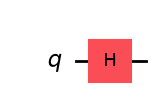

In [40]:
from qiskit.circuit.library import HGate

circuito_plus = QuantumCircuit(1)

# Aplicar H al qubit 0
circuito_plus.h(0)

estado_plus = Statevector.from_instruction(circuito_plus)
ket_plus_numpy = np.array([1 / np.sqrt(2), 1 / np.sqrt(2)], dtype=complex)

# Circuito
print("Circuito:")
print(circuito_plus.draw())

# Matriz de H
print("Matriz de H:")
print(Operator(HGate()).data)

# Amplitudes: Qiskit frente a NumPy
print("\nAmplitudes Qiskit:", estado_plus.data)
print("Amplitudes NumPy: ", ket_plus_numpy)
print("¿Coinciden las amplitudes?", np.allclose(estado_plus.data, ket_plus_numpy))
print("Norma:", np.linalg.norm(estado_plus.data))

# Probabilidades exactas
probabilidades_numpy = np.abs(ket_plus_numpy) ** 2
print("\nProbabilidades Qiskit:", estado_plus.probabilities())
print("Probabilidades NumPy: ", probabilidades_numpy)
print("probabilities_dict():", estado_plus.probabilities_dict())
print("¿Coinciden las probabilidades?", np.allclose(estado_plus.probabilities(), probabilidades_numpy))

# Visualización con Matplotlib
circuito_plus.draw("mpl")

## Ejercicio 21. Medida de la superposición

Crea una copia, añade medidas y ejecútala con 10, 100, 1.000 y 10.000 shots. Calcula $f(0)$, $f(1)$ y $|f(0)-1/2|$.

In [42]:
circuito_plus_medida = circuito_plus.copy()

# Añadir medidas a la copia (circuito_plus no tiene bits clásicos)
circuito_plus_medida.measure_all()

print("Circuito con medidas:")
print(circuito_plus_medida.draw())
print("¿Sigue circuito_plus sin medidas?", circuito_plus.count_ops().get("measure", 0) == 0)

shots_superposicion = [10, 100, 1_000, 10_000]
resultados_superposicion = []

for shots in shots_superposicion:
    conteos = ejecutar_con_shots(circuito_plus_medida, shots=shots, semilla=42)
    frecuencias = calcular_frecuencias(conteos)

    f_0 = frecuencias.get("0", 0)
    f_1 = frecuencias.get("1", 0)

    resultados_superposicion.append({
        "shots": shots,
        "conteos": conteos,
        "frecuencia_0": f_0,
        "frecuencia_1": f_1,
        "error": abs(f_0 - 0.5),
        "error_tipico_teorico": 0.5 / np.sqrt(shots),
    })

# Tabla de resultados
print(f"\n{'Shots':>6} | {'Conteos':<24} | {'f(0)':>6} | {'f(1)':>6} | {'|f(0)-1/2|':>10} | {'0,5/√N':>7}")
print("-" * 76)
for fila in resultados_superposicion:
    print(f"{fila['shots']:>6} | {str(fila['conteos']):<24} | {fila['frecuencia_0']:>6.4f} | {fila['frecuencia_1']:>6.4f} | {fila['error']:>10.4f} | {fila['error_tipico_teorico']:>7.4f}")

Circuito con medidas:
        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 
¿Sigue circuito_plus sin medidas? True

 Shots | Conteos                  |   f(0) |   f(1) | |f(0)-1/2| |  0,5/√N
----------------------------------------------------------------------------
    10 | {'1': 5, '0': 5}         | 0.5000 | 0.5000 |     0.0000 |  0.1581
   100 | {'1': 51, '0': 49}       | 0.4900 | 0.5100 |     0.0100 |  0.0500
  1000 | {'1': 486, '0': 514}     | 0.5140 | 0.4860 |     0.0140 |  0.0158
 10000 | {'0': 4921, '1': 5079}   | 0.4921 | 0.5079 |     0.0079 |  0.0050


### Responde

1. ¿Coinciden exactamente frecuencias y probabilidades?
2. ¿Qué sucede normalmente al aumentar los shots?
3. ¿Debe disminuir estrictamente el error en cada fila?
4. ¿Qué diferencia hay respecto a $|0\rangle$ y $|1\rangle$?
5. ¿Se conserva la fase en los conteos?

**Respuesta:**

1. En general, no. Las probabilidades exactas son $P(0) = P(1) = 0{,}5$, pero las frecuencias se obtienen de un número finito de shots en los que cada resultado es aleatorio, así que fluctúan alrededor de 0,5. Solo coincidirían exactamente por casualidad. Las frecuencias son una estimación experimental de las probabilidades, no su valor exacto.

2. Las frecuencias tienden a acercarse a las probabilidades exactas (ley de los grandes números), así que el error $|f(0) - 1/2|$ suele disminuir. El error típico esperado es $\sqrt{p(1-p)/N} = 0{,}5/\sqrt{N}$, que decrece como $1/\sqrt{N}$. Para reducir el error a la décima parte hay que multiplicar el número de shots por 100.

3. No. La convergencia es estadística: lo que disminuye con $N$ es el error esperado, no el error de cada ejecución concreta. Por azar, una ejecución con más shots puede dar un error mayor que otra con menos. Por eso los errores de la tabla deben compararse con el error típico teórico $0{,}5/\sqrt{N}$, que sí decrece estrictamente, y no entre sí fila a fila.

4. Al medir $|0\rangle$ o $|1\rangle$, el resultado es determinista: siempre se obtiene el mismo valor, las frecuencias coinciden exactamente con las probabilidades (0 o 1) sea cual sea el número de shots, y no hay error estadístico. Al medir $|+\rangle$, cada shot da un resultado aleatorio, así que aparece incertidumbre estadística y hacen falta muchos shots para estimar bien las probabilidades. Esta aleatoriedad es propia de la medida cuántica y aparece aunque el simulador sea ideal, sin ruido.

5. No. Los conteos solo permiten estimar las probabilidades $|\alpha_x|^2$, y la fase se pierde al medir. Por ejemplo, el estado $|-\rangle = (|0\rangle - |1\rangle)/\sqrt{2}$ tiene una fase relativa distinta de la de $|+\rangle$, pero al medirlo en la base computacional produciría conteos con la misma distribución (aproximadamente mitad `0` y mitad `1`). Con los conteos no se pueden distinguir ambos estados.

## Ejercicio 22. Gráfica de convergencia

Representa shots frente a frecuencia de 0, con eje horizontal logarítmico y una línea teórica en 0,5. Interpreta la gráfica.

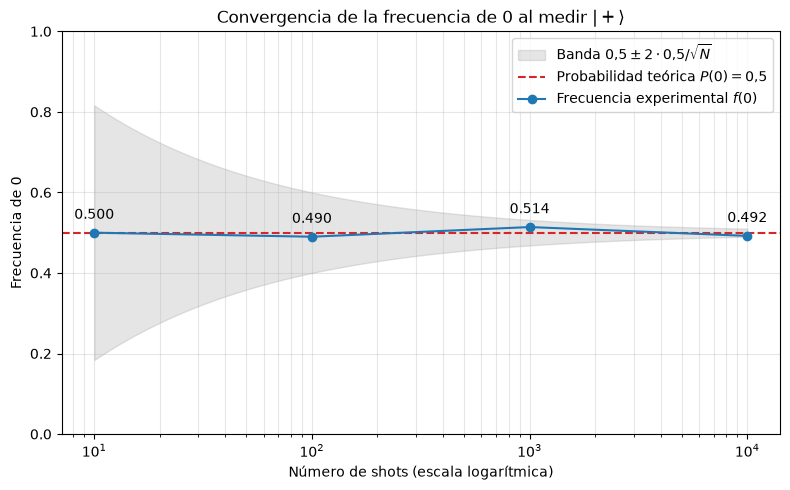

In [43]:
# Extraer los datos del ejercicio 21
shots_grafica = np.array([fila["shots"] for fila in resultados_superposicion])
frecuencias_0 = np.array([fila["frecuencia_0"] for fila in resultados_superposicion])

# Banda de ±2 errores típicos alrededor del valor teórico
shots_continuos = np.logspace(np.log10(shots_grafica.min()), np.log10(shots_grafica.max()), 200)
error_tipico = 0.5 / np.sqrt(shots_continuos)

fig, ax = plt.subplots(figsize=(8, 5))

ax.fill_between(shots_continuos, 0.5 - 2 * error_tipico, 0.5 + 2 * error_tipico,
                color="tab:gray", alpha=0.2, label=r"Banda $0{,}5 \pm 2 \cdot 0{,}5/\sqrt{N}$")
ax.axhline(0.5, color="tab:red", linestyle="--", label="Probabilidad teórica $P(0) = 0{,}5$")
ax.plot(shots_grafica, frecuencias_0, marker="o", color="tab:blue", label="Frecuencia experimental $f(0)$")

# Valor de cada punto
for n, f in zip(shots_grafica, frecuencias_0):
    ax.annotate(f"{f:.3f}", (n, f), textcoords="offset points", xytext=(0, 10), ha="center")

ax.set_xscale("log")
ax.set_xlabel("Número de shots (escala logarítmica)")
ax.set_ylabel("Frecuencia de 0")
ax.set_title("Convergencia de la frecuencia de 0 al medir $|+\\rangle$")
ax.set_ylim(0, 1)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:** La gráfica muestra la frecuencia experimental de `0` al medir $|+\rangle$ con 10, 100, 1.000 y 10.000 shots, junto con la probabilidad teórica $P(0) = 0{,}5$ (línea discontinua).

Con pocos shots, la frecuencia puede alejarse bastante de 0,5, porque cada resultado es aleatorio y unos pocos shots bastan para desequilibrar la proporción. Al aumentar el número de shots, la frecuencia tiende a acercarse a 0,5, como predice la ley de los grandes números. La banda sombreada representa el margen esperado, $0{,}5 \pm 2 \cdot 0{,}5/\sqrt{N}$, y muestra que las fluctuaciones disminuyen como $1/\sqrt{N}$: cada vez que se multiplican los shots por 100, el margen se reduce a la décima parte. Por eso se usa la escala logarítmica, que permite ver en la misma gráfica valores de $N$ que abarcan varios órdenes de magnitud.

La convergencia es estadística y no monótona: un punto con más shots no tiene por qué estar más cerca de 0,5 que el anterior, aunque sí debe quedar, normalmente, dentro de una banda más estrecha. En cualquier caso, la frecuencia nunca coincide con certeza con la probabilidad: con un número finito de shots siempre queda un error de muestreo, que solo se reduce aumentando los shots.

## Ejercicio 23. Comparación exacta y experimental

Con 10.000 shots, construye una tabla con resultado, amplitud, probabilidad exacta, conteo y frecuencia.

In [44]:
# Datos experimentales con 10.000 shots (del ejercicio 21)
fila_10000 = next(fila for fila in resultados_superposicion if fila["shots"] == 10_000)
conteos_10000 = fila_10000["conteos"]
frecuencias_10000 = calcular_frecuencias(conteos_10000)

# Datos exactos (del ejercicio 20)
amplitudes_plus = estado_plus.data
probabilidades_plus = estado_plus.probabilities()

# Tabla comparativa
print(f"{'Resultado':>9} | {'Amplitud':>16} | {'P. exacta':>9} | {'Conteo':>6} | {'Frecuencia':>10} | {'|f - P|':>7}")
print("-" * 75)
for indice, resultado in enumerate(["0", "1"]):
    amplitud = amplitudes_plus[indice]
    probabilidad = probabilidades_plus[indice]
    conteo = conteos_10000.get(resultado, 0)
    frecuencia = frecuencias_10000.get(resultado, 0)
    print(f"{resultado:>9} | {str(np.round(amplitud, 5)):>16} | {probabilidad:>9.4f} | "
          f"{conteo:>6} | {frecuencia:>10.4f} | {abs(frecuencia - probabilidad):>7.4f}")

# Comprobaciones
print("\nSuma de probabilidades exactas:", probabilidades_plus.sum())
print("Suma de conteos:", sum(conteos_10000.values()))
print("Suma de frecuencias:", sum(frecuencias_10000.values()))

Resultado |         Amplitud | P. exacta | Conteo | Frecuencia | |f - P|
---------------------------------------------------------------------------
        0 |     (0.70711+0j) |    0.5000 |   4921 |     0.4921 |  0.0079
        1 |     (0.70711+0j) |    0.5000 |   5079 |     0.5079 |  0.0079

Suma de probabilidades exactas: 0.9999999999999998
Suma de conteos: 10000
Suma de frecuencias: 1.0


### Responde

1. ¿Qué columnas proceden de `Statevector`?
2. ¿Cuáles requieren medida?
3. ¿Cuál conserva información de fase?
4. ¿Por qué los conteos no reconstruyen el estado completo?

**Respuesta:**

1. La amplitud y la probabilidad exacta. La amplitud es directamente el contenido de `estado_plus.data`, y la probabilidad exacta se obtiene con `estado_plus.probabilities()`, que calcula el módulo al cuadrado de cada amplitud. Ambas son valores teóricos: se calculan sin medir, sin shots y sin aleatoriedad, así que son iguales en cada ejecución.

2. El conteo y la frecuencia. Se obtienen ejecutando el circuito con medidas (`circuito_plus_medida`) en `AerSimulator` con 10.000 shots: el conteo es el número de veces que aparece cada resultado y la frecuencia es ese conteo dividido entre el total de shots. Son valores experimentales, sujetos a fluctuaciones estadísticas, que dependen del número de shots y de la semilla. La columna $|f - P|$ mide la diferencia entre ambos mundos, el exacto y el experimental.

3. Solo la amplitud. Es un número complejo $\alpha = |\alpha| e^{i\varphi}$ que contiene tanto el módulo como la fase. La probabilidad exacta $|\alpha|^2$ pierde la fase, y los conteos y frecuencias, que estiman esa probabilidad, tampoco la contienen.

4. Por dos motivos. Primero, la medida en la base computacional solo da acceso a los módulos $|\alpha_x|^2$ y destruye la información de fase, así que estados con distinta fase relativa, como $|+\rangle$ y $|-\rangle$, producen la misma distribución de conteos. Segundo, con un número finito de shots los conteos solo estiman las probabilidades, con un error de muestreo. Además, cada medida colapsa el estado, de modo que no puede estudiarse repetidamente el mismo estado: cada shot requiere prepararlo de nuevo. Para reconstruir el estado completo habría que medir en varias bases distintas (tomografía cuántica de estados).

# Parte H. Circuitos de dos qubits

## Ejercicio 24. Estado inicial

Crea dos qubits, obtén el vector y el diccionario de probabilidades, y comprueba que representan $|00\rangle$.

In [46]:
circuito_00 = QuantumCircuit(2)
estado_00 = Statevector.from_instruction(circuito_00)

# Vector y dimensión
print("Vector de estado:")
print(estado_00)
print("Array data:", estado_00.data)
print("Número de amplitudes:", len(estado_00.data))
print("Dimensión:", estado_00.dim)
print("Dimensiones de cada qubit:", estado_00.dims())

# Probabilidades
print("\nprobabilities():     ", estado_00.probabilities())
print("probabilities_dict():", estado_00.probabilities_dict())

# Comparación con |00> = |0> ⊗ |0> construido con NumPy
ket_00_numpy = np.kron(ket_0_numpy, ket_0_numpy)
print("\n|00> en NumPy (producto tensorial):", ket_00_numpy)
print("¿Coinciden?", np.allclose(estado_00.data, ket_00_numpy))

# Orden de la base: índice del vector y etiqueta
print("\nOrden de la base:")
for indice, amplitud in enumerate(estado_00.data):
    print(f"  índice {indice} -> |{indice:02b}> : amplitud {amplitud}")

# Comprobación para la pregunta 4: tres qubits
estado_000 = Statevector.from_instruction(QuantumCircuit(3))
print("\nDimensión con tres qubits:", estado_000.dim)

Vector de estado:
Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
Array data: [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
Número de amplitudes: 4
Dimensión: 4
Dimensiones de cada qubit: (2, 2)

probabilities():      [1. 0. 0. 0.]
probabilities_dict(): {np.str_('00'): np.float64(1.0)}

|00> en NumPy (producto tensorial): [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
¿Coinciden? True

Orden de la base:
  índice 0 -> |00> : amplitud (1+0j)
  índice 1 -> |01> : amplitud 0j
  índice 2 -> |10> : amplitud 0j
  índice 3 -> |11> : amplitud 0j

Dimensión con tres qubits: 8


### Responde

1. ¿Cuántas amplitudes contiene?
2. ¿Por qué son cuatro?
3. ¿Cuál es el orden de la base?
4. ¿Qué dimensión tendrá un estado de tres qubits?

**Respuesta:**

1. Cuatro: $(1, 0, 0, 0)^T$. La amplitud de $|00\rangle$ es 1 y las de $|01\rangle$, $|10\rangle$ y $|11\rangle$ son 0. Por tanto, el estado es $|00\rangle$, con $P(00) = 1$, como confirma `probabilities_dict()`.

2. Porque el espacio de estados de dos qubits es el producto tensorial de los espacios de cada qubit: $\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$. Hay una amplitud por cada combinación posible de valores de los dos qubits, y como cada qubit puede valer 0 o 1, hay $2 \times 2 = 4$ combinaciones. Además, como ambos qubits empiezan en $|0\rangle$, el estado inicial es $|0\rangle \otimes |0\rangle = |00\rangle$, que coincide con `np.kron(ket_0_numpy, ket_0_numpy)`.

3. El orden es $|00\rangle, |01\rangle, |10\rangle, |11\rangle$, es decir, el índice $k$ del vector corresponde al número $k$ escrito en binario. Qiskit usa el convenio *little-endian*: en cada etiqueta, el qubit $q_0$ es el bit de la derecha (el menos significativo) y $q_1$ el de la izquierda, es decir, la etiqueta se lee como $|q_1 q_0\rangle$. Así, el índice 1 corresponde a $|01\rangle$, que significa $q_0 = 1$ y $q_1 = 0$. Este convenio es la clave del ejercicio 26.

4. $2^3 = 8$. En general, un estado de $n$ qubits tiene dimensión $2^n$, por lo que el número de amplitudes crece exponencialmente con el número de qubits. Por eso simular circuitos grandes en un ordenador clásico se vuelve inviable muy rápido: con 50 qubits harían falta unos $10^{15}$ números complejos.

## Ejercicio 25. Base computacional de dos qubits
Construye circuitos para $|00\rangle$, $|01\rangle$, $|10\rangle$ y $|11\rangle$. Dibuja cada uno y muestra su vector y `probabilities_dict()`.

In [26]:
# TODO: construye los cuatro circuitos
circuitos_base_2q = {
    "|00>": circuito_00,
    # Completa el diccionario
}

# TODO: visualiza y analiza todos los circuitos

## Ejercicio 26. Orden de bits

Aplica `x(0)` a dos qubits. Muestra el vector y el diccionario de probabilidades.

In [27]:
circuito_orden = QuantumCircuit(2)

# TODO: aplica X a q_0 y analiza el estado

### Responde

1. ¿Por qué aparece `"01"` y no `"10"`?
2. ¿Qué valores tienen $q_0$ y $q_1$?
3. ¿En qué orden se muestran las cadenas?
4. ¿Cuál es el orden del vector de amplitudes?

**Respuesta:** TODO

## Ejercicio 27. Medida de dos qubits

Para los cuatro estados de la base, crea copias con dos bits clásicos, mide cada qubit en el bit del mismo índice y ejecuta 1.000 shots.

In [28]:
conteos_base_2q = {}

# TODO: añade medidas, ejecuta y almacena conteos para los cuatro estados

## Ejercicio 28. Intercambio de bits clásicos
Prepara $|01\rangle$ y compara la medida directa `q0→c0, q1→c1` con la medida intercambiada `q0→c1, q1→c0`.

In [29]:
# TODO: crea y ejecuta ambos circuitos

### Responde

1. ¿Cambia el estado anterior a la medida?
2. ¿Cambia la cadena clásica?
3. ¿Qué demuestra el experimento?
4. ¿Por qué debe revisarse el mapeo entre qubits y bits?

**Respuesta:** TODO

# Parte I. Interpretación conceptual

## Ejercicio 29. Clasificación

Clasifica y justifica: `QuantumCircuit(2,2)`, `Statevector.from_instruction(c)`, `estado.data`, `estado.probabilities()`, `measure()`, `"01"`, `{"00":492,"11":508}`, `492/1000`, `plot_histogram()` y `simulador.run()`.

**Respuesta:** TODO

## Ejercicio 30. Verdadero o falso

Justifica:

1. Crear un circuito lo ejecuta inmediatamente.
2. Los qubits comienzan por defecto en $|0\rangle$.
3. Un bit clásico puede contener una superposición.
4. Declarar bits clásicos añade medidas.
5. `Statevector.data` contiene amplitudes.
6. `probabilities_dict()` devuelve conteos.
7. Cada shot incluye una nueva preparación.
8. El histograma muestra amplitudes.
9. La transpilación adapta el circuito al backend.
10. Dos circuitos distintos pueden producir el mismo estado final.
11. Probabilidades iguales implican amplitudes iguales.
12. Qiskit muestra $q_0$ a la izquierda de las cadenas.
13. `x(0)` sobre dos qubits prepara $|01\rangle$.
14. Un simulador ideal incluye ruido automáticamente.
15. La medida puede eliminar información de fase.

**Respuesta:** TODO

# Reto avanzado. Analizador de circuitos

Implementa una función que reciba un circuito sin medidas y devuelva el vector, probabilidades exactas, una copia con medidas, conteos y frecuencias. Debe validar el tipo, los shots y que el circuito no contenga medidas.

In [30]:
def analizar_circuito(circuito_sin_medidas, shots=1000, semilla=42):
    """Analiza exactamente un circuito y simula después sus medidas."""
    # TODO
    pass


# TODO: pruébala con circuitos vacío, X, XX, H y |01>

### Responde

1. ¿Qué parte es exacta?
2. ¿Qué parte depende de los shots?
3. ¿Qué información desaparece en los conteos?
4. ¿Por qué se conserva el circuito original sin medidas?
5. ¿Cómo comprobarías la coherencia entre conteos y shots?

**Respuesta:** TODO

# Pruebas mínimas

Descomenta estas pruebas al completar la práctica y añade casos inválidos.

In [31]:
# assert circuito_0.num_qubits == 1
# assert circuito_0.num_clbits == 0
# assert np.allclose(estado_0.data, [1, 0])
# assert np.allclose(estado_1.data, [0, 1])
# assert np.allclose(estado_xx.data, [1, 0])
# assert np.allclose(X_numpy @ ket_0_numpy, estado_1.data)
# assert sum(conteos_0.values()) == 1000
# assert conteos_0.get("0", 0) == 1000
# assert np.allclose(estado_plus.probabilities(), [0.5, 0.5])

# TODO: añade pruebas de frecuencias, dos qubits, shots inválidos,
# conteos inválidos y conservación del circuito original